# Outlier Detection and Removal using the IQR method

### When to use: When data is skewed and is not normally distributed

### Concept:- IQR proximity rule, Outliers:   Less than Q1 - 1.5 IQR  or  Greater than Q3 + 1.5 IQR  , where Q1 and Q3 are 25th and 75th percentiles respectively, and IQR = Q3 - Q1

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
df = pd.read_csv('placement.csv')

In [46]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [47]:
df.shape

(1000, 3)

## Visualizing the distributions of cgpa and placement_exam_marks columns

C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='placement_exam_marks', ylabel='Density'>

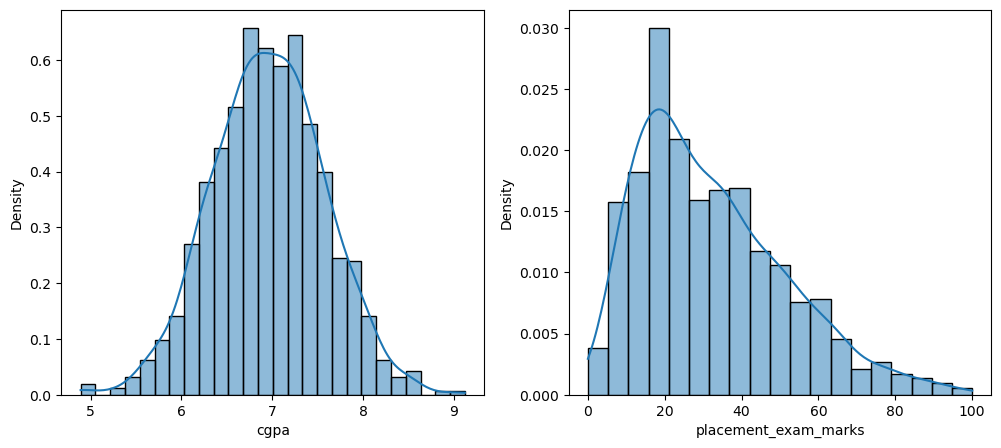

In [48]:
fig ,(ax1, ax2) = plt.subplots(1, 2,figsize=(12,5))

sns.histplot(df['cgpa'], ax=ax1, kde=True, stat='density')
sns.histplot(df['placement_exam_marks'], ax=ax2, kde=True, stat='density')

In [49]:
df['cgpa'].skew(), df['placement_exam_marks'].skew()

(-0.014529938929314918, 0.8356419499466834)

#### Outlier removal using IQR method is suitable for skewed data, hence we apply it on placement_exam_marks columns which is right skewed

In [50]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: >

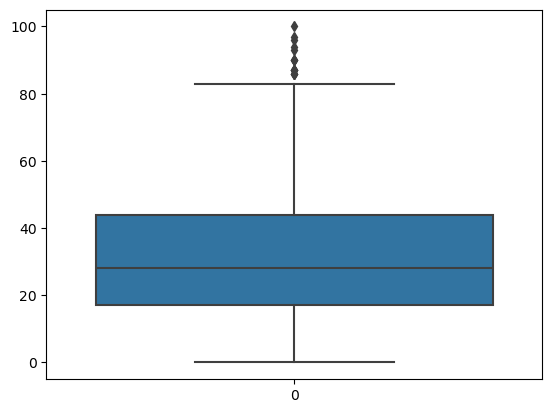

In [51]:
sns.boxplot(df['placement_exam_marks'])

# Trimming

In [52]:
Q1 = df['placement_exam_marks'].quantile(0.25)
Q3 = df['placement_exam_marks'].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5* IQR
lower_limit = Q1 - 1.5* IQR

In [53]:
upper_limit , lower_limit

(84.5, -23.5)

In [54]:
# finding outliers
df[(df['placement_exam_marks'] > upper_limit) | (df['placement_exam_marks'] < lower_limit)]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


### Trimming 

In [55]:
df_new = df[df['placement_exam_marks'] < upper_limit] # no outliers below lower limit


In [56]:
df_new.shape

(985, 3)

C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: title={'center': 'After removal of outliers'}, xlabel='placement_exam_marks', ylabel='Density'>

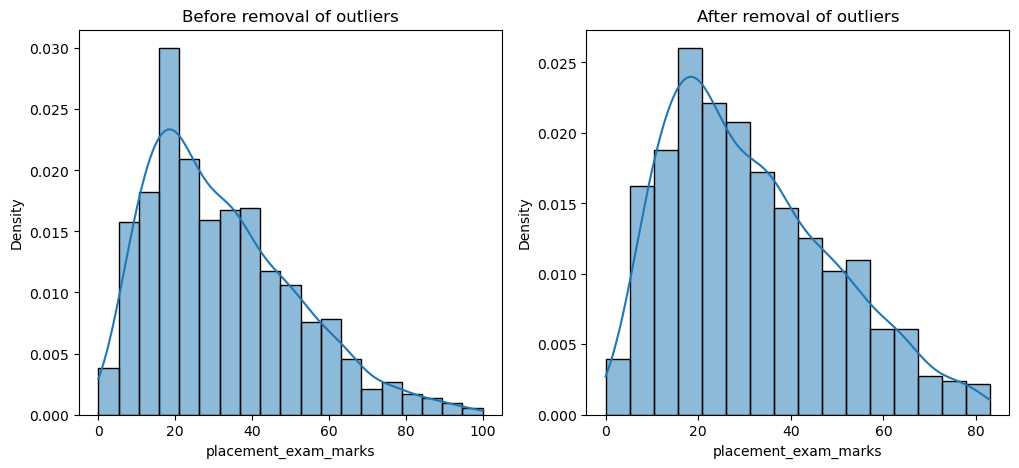

In [57]:
# comparing the distribution before and after outlier removal
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

ax1.set_title('Before removal of outliers')
ax2.set_title('After removal of outliers')

sns.histplot(df['placement_exam_marks'], stat='density', kde='True', ax=ax1)
sns.histplot(df_new['placement_exam_marks'], stat='density', kde='True', ax=ax2)

<Axes: title={'center': 'After removal of outliers'}>

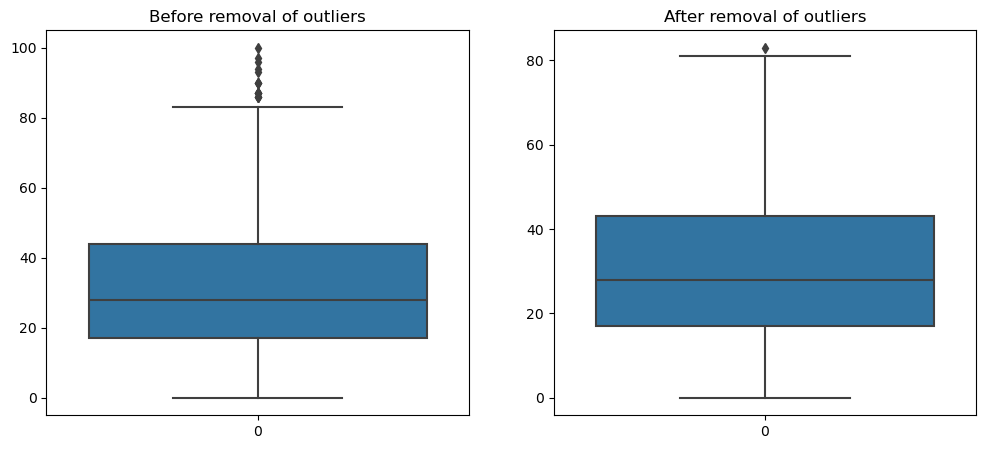

In [58]:
#comparing the boxplots before and after
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

ax1.set_title('Before removal of outliers')
ax2.set_title('After removal of outliers')

sns.boxplot(df['placement_exam_marks'],  ax=ax1)
sns.boxplot(df_new['placement_exam_marks'], ax=ax2)

# Capping


In [59]:
new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    df['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        df['placement_exam_marks'] < lower_limit,
        lower_limit,
        df['placement_exam_marks']
    )
)

In [60]:
df.shape

(1000, 3)

C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: title={'center': 'After capping of outliers'}, xlabel='placement_exam_marks', ylabel='Density'>

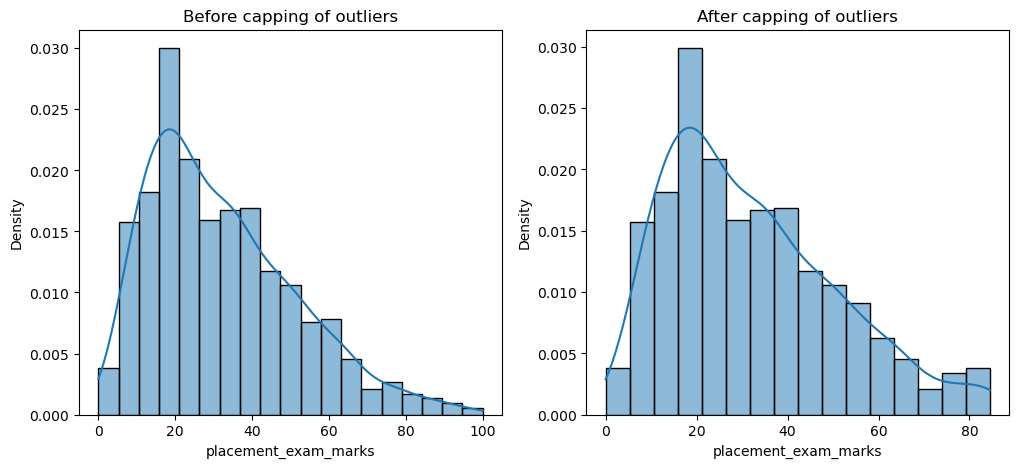

In [61]:
# comparing the distribution before and after outlier removal
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

ax1.set_title('Before capping of outliers')
ax2.set_title('After capping of outliers')

sns.histplot(df['placement_exam_marks'], stat='density', kde='True', ax=ax1)
sns.histplot(new_df_cap['placement_exam_marks'], stat='density', kde='True', ax=ax2)

#### We can see a small peak around the upper_limit i.e. at 84.5 after capping

<Axes: title={'center': 'After capping of outliers'}>

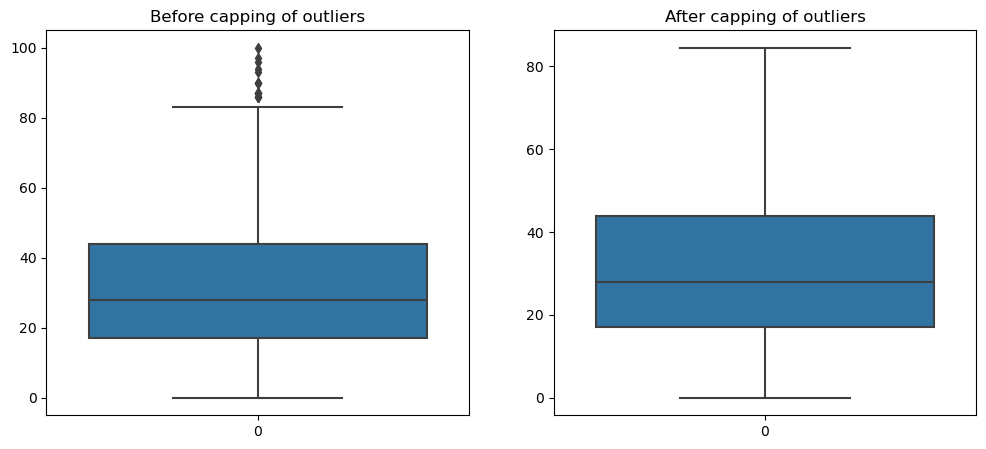

In [62]:
#comparing the boxplots before and after
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

ax1.set_title('Before capping of outliers')
ax2.set_title('After capping of outliers')

sns.boxplot(df['placement_exam_marks'],  ax=ax1)
sns.boxplot(new_df_cap['placement_exam_marks'], ax=ax2)

In [63]:
df.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.225000,0.489000
std,0.615898,19.130822,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,100.000000,1.000000


In [64]:
new_df_cap.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.136500,0.489000
std,0.615898,18.865419,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,84.500000,1.000000
